
# ⏱️ Time Series

Time series data is a type of data that is collected and recorded at specific time intervals, typically in chronological order. Each observation in a time series corresponds to a particular point in time, and the key feature of this data is the temporal ordering—the order in which the data points occur matters and carries important information for analysis and forecasting.

## Key Features of Time Series Data

### Temporal Dependence
Unlike typical datasets where observations are assumed to be independent, time series data often exhibits temporal dependence, meaning that past values influence future values. This sequential nature is central to how we model and forecast time series.

### Regular vs. Irregular Intervals
Time series data can be:

- **Regularly spaced** — e.g., hourly temperature readings, daily stock prices, monthly sales  
- **Irregularly spaced** — e.g., timestamps of earthquakes or hospital admissions  

Most forecasting methods assume regular intervals, so irregular data may need preprocessing to become suitable for analysis.

### Trends, Seasonality, and Cycles
Time series often contain patterns:

- **Trend:** A long-term increase or decrease in the data  
- **Seasonality:** Regular repeating patterns over fixed periods (e.g., daily, weekly, yearly)  
- **Cycles:** Fluctuations that are not of fixed period, often tied to economic or external factors  

Understanding and separating these components is a major step in time-series modeling.

### Stationarity
A time series is said to be stationary if its statistical properties—mean, variance, and autocorrelation—remain constant over time. Many modeling methods (like ARIMA) require the data to be stationary. We often transform non-stationary series using techniques like differencing.

### Autocorrelation
Autocorrelation measures how related a current observation is to its past values. It helps determine lag relationships and is foundational in many time series models.

## Time-Series Data Uniqueness

- **Order matters:** You can’t randomly shuffle rows without destroying the structure  
- **Past affects the future:** Historical values can explain or predict outcomes  
- **Requires special methods:** Standard ML assumes i.i.d. data, which doesn’t apply to time series  

This is why methods such as ARIMA, exponential smoothing, and feature-based ML approaches are required.

## Parsing Dates and Setting the Time Index

Time-series data typically comes with a timestamp column that must be converted to datetime format and set as the DataFrame index. This enables powerful time-based operations such as resampling, shifting, and rolling calculations.


In [50]:

import pandas as pd


df = pd.read_csv("/Users/guywinfield/PycharmProjects/Data/walmart-recruiting-store-sales-forecasting/features.csv")

df.head()
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


In [51]:
df.sort_values(by=['Date'], inplace=True)
df.head()


,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
Date,,,,,,,,,,,
2010-02-05,1,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
2010-02-05,16,19.79,2.580,NaN,NaN,NaN,NaN,NaN,189.381697,7.039,False
2010-02-05,31,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,False
2010-02-05,21,39.05,2.572,NaN,NaN,NaN,NaN,NaN,210.752605,8.324,False
2010-02-05,26,9.55,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,8.488,False


In [52]:
df.dtypes

Store             int64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object


## Visualizing Time-Series Data

Plotting is the first step in understanding trends, seasonality, and potential outliers. Line plots help visualise the general shape of the series.


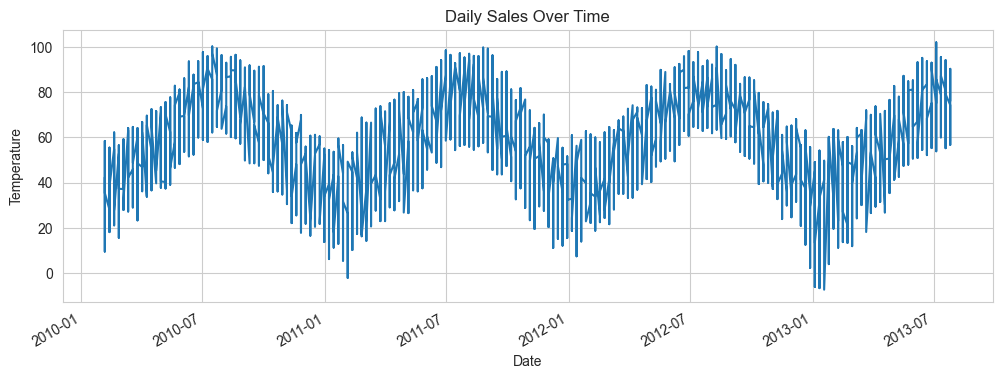

In [53]:

import matplotlib.pyplot as plt

df['Temperature'].plot(figsize=(12, 4), title="Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()



## Handling Missing Data

Time-series datasets often have missing dates or values. One strategy is to fill in missing dates and impute missing values appropriately.


In [54]:

df = df.asfreq('D')
df['Temperature'].fillna(method='ffill', inplace=True)


ValueError: cannot reindex on an axis with duplicate labels


## Seasonal Decomposition


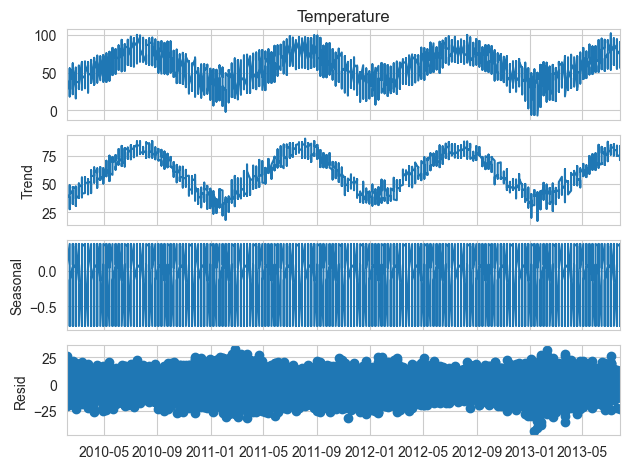

In [55]:

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Temperature'], model='additive', period=7)
decomposition.plot()
plt.show()



## Resampling Data

If your data is too granular or not aligned with the desired frequency, you can resample it. For example, converting daily data into monthly totals.


In [56]:

monthly_sales = df['Temperature'].resample('M').sum()


/var/folders/kn/24kjgmss2yzfjngp_zf6x8vr0000gn/T/ipykernel_33836/2832430452.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Temperature'].resample('M').sum()



## Smoothing and Noise Reduction

Smoothing techniques help highlight long-term trends by reducing short-term fluctuations. A common method is the moving average.


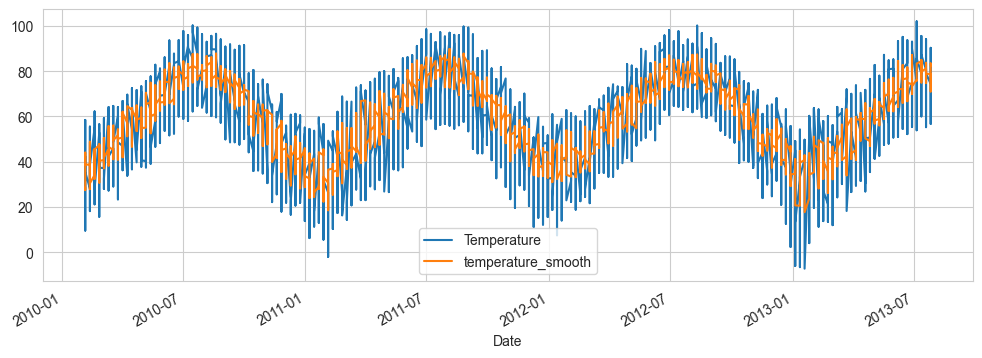

In [57]:

df['temperature_smooth'] = df['Temperature'].rolling(window=7).mean()
df[['Temperature', 'temperature_smooth']].plot(figsize=(12, 4))
plt.show()



## Checking for Stationarity

Many forecasting models assume stationarity. You can visually inspect rolling statistics and statistically test using the Augmented Dickey-Fuller (ADF) test.


In [58]:

from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Temperature'].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


ADF Statistic: -2.1112411158417097
p-value: 0.24001858276391375



A p-value less than 0.05 typically suggests the data is stationary. If it isn’t, differencing is often used.



## Differencing for Stationarity


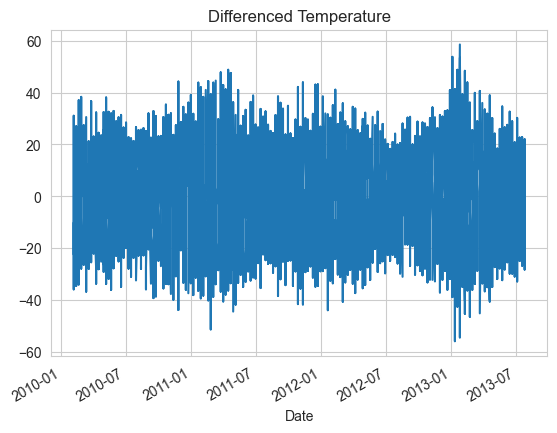

In [59]:

df['temperature_diff'] = df['Temperature'] - df['Temperature'].shift(1)
df['temperature_diff'].dropna().plot(title='Differenced Temperature')
plt.show()



## Modelling

Once your data is prepared and explored, the next step is forecasting. Time-series models fall into classical statistical models and machine learning approaches adapted for time series.



## Naïve and Simple Models


In [60]:

naive_forecast = df['Temperature'].shift(1)
df['moving_avg'] = df['Temperature'].rolling(window=3).mean()



## Exponential Smoothing Methods


In [61]:

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

ses_model = SimpleExpSmoothing(df['Temperature']).fit()
ses_forecast = ses_model.forecast(10)

holt_model = Holt(df['Temperature']).fit()
holt_forecast = holt_model.forecast(10)

hw_model = ExponentialSmoothing(
    df['Temperature'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()
hw_forecast = hw_model.forecast(12)


/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date ind


## ARIMA Models


In [62]:

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Temperature'], order=(2, 1, 2))
model_fit = model.fit()
forecast = model_fit.forecast(steps=10)


/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No suppor


## Seasonal ARIMA (SARIMA)


In [63]:

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['Temperature'], order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)


/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is av


## Machine Learning Approaches for Time Series


In [64]:

df['lag_1'] = df['Temperature'].shift(1)
df['lag_7'] = df['Temperature'].shift(7)
df['rolling_mean_7'] = df['Temperature'].rolling(window=7).mean()
df.dropna(inplace=True)


In [65]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features = ['lag_1', 'lag_7', 'rolling_mean_7']
X = df[features]
y = df['Temperature']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)



## Evaluation

Evaluating forecasting models requires respecting temporal order. Common strategies include train-test splits by time, walk-forward validation, and expanding window validation.



### Useful Metrics

- MAE  
- MSE / RMSE  
- MAPE  
- sMAPE  
- Forecast Bias  
- Prediction Intervals  


# Ranking

In many real-world tasks, the goal isn’t just to make a prediction—but to rank a set of items in order of relevance or importance. This is the essence of a ranking problem. Whether it’s showing the most relevant web pages for a search query, recommending top movies to a user, or prioritizing job listings, ranking helps surface the best options first. Unlike classification or regression, ranking focuses on relative preferences—how items compare to each other in a specific context.

Ranking problems can be modeled in different ways: pointwise, where each item is scored individually; pairwise, where the model learns from item comparisons; and listwise, where the entire item list is considered during training. In this sprint, you’ll explore these approaches, learn to evaluate rankings using metrics like NDCG and MAP, and implement practical ranking models using tree-based learners like LightGBM—no deep learning required.

### Ranking Problem

Ranking problems involve ordering a set of items so that the most relevant or important items appear at the top of the list. Unlike traditional supervised learning tasks such as classification or regression, ranking focuses on relative comparisons between items rather than predicting an absolute class or value for each item independently.

In ranking tasks, data is usually organized around queries or contexts. For each query—think of a search term, user profile, or any specific request—you have a list of candidate items to rank. Your goal is to build a model that assigns a score to each item based on features describing the item itself and, often, its relationship to the query. When you sort the items by these scores, the best or most relevant ones should appear at the top.

Each item is labeled to indicate how relevant or useful it is for that query. These labels might be simple (like relevant or not relevant) or more detailed (like ratings from 1 to 5). Importantly, the same item might have different relevance for different queries—so your model must learn to handle this context dependency.

- Context matters: The relevance of an item depends on the specific query or user. The same item might be highly relevant in one context and less relevant in another.
- Focus on order, not just scores: The goal is to get the order of items right, more than just predicting exact relevance values.
- Grouped data: You work with groups of items tied to each query, not just isolated data points.

### Ranking Methods

Ranking problems can be tackled in several ways, depending on how you treat the data and what your model learns. The three main approaches are pointwise, pairwise, and listwise ranking. Each has its strengths and trade-offs.

**Pointwise Ranking**

In the pointwise approach, the model treats ranking like a standard regression or classification problem. It looks at each item individually and tries to predict its relevance score or class (e.g., relevant or not). Once you have predicted scores for all items related to a query, you simply sort them to get the ranking.

 Pros:
- Simple to implement and understand
- Can use any standard regression or classification model

Cons:
- Ignores the relative ordering between items
- May not optimize ranking metrics directly

**Pairwise Ranking**

Pairwise ranking focuses on learning preferences between pairs of items. Instead of scoring items independently, the model learns to predict which item in a pair is more relevant. By comparing many such pairs, the model implicitly learns how to rank the full list.

For example, given two documents A and B for a query, the model learns which one should be ranked higher.

Pros:
- Captures relative preferences directly
- Often improves ranking performance over pointwise methods

Cons:
- Requires generating many pairs, which can be computationally expensive
- Does not consider the full list order at once

**Listwise Ranking**

The listwise approach looks at the entire list of items for a query during training. It directly optimizes a loss function based on the quality of the predicted ranked list, often aligning better with ranking evaluation metrics like NDCG.

Listwise methods consider interactions among all items together, learning to produce the best overall ordering.

Pros:
- Directly optimizes ranking metrics
- Typically achieves the best performance in practice

Cons:
- More complex to implement and compute
-  Often requires specialized algorithms



### Ranking metrics

**Precision@K**

Precision@K calculates the fraction of relevant items in the top K positions. It’s straightforward and useful when relevance is binary (relevant or not). However, it doesn’t account for the position of relevant items within the top K or graded relevance.



In [71]:
import numpy as np

def precision_at_k(y_true: list[float], y_score: list[float], k: int) -> float:
    idx = np.argsort(y_score)[::-1][:k]
    relevant_at_k = np.sum(np.array(y_true)[idx] > 0)
    return relevant_at_k / k

y_true = [1, 0, 1, 0, 1]       # Relevant items at positions 0, 2, 4
y_score = [0.9, 0.2, 0.8, 0.1, 0.7]  # Predicted scores

print("Precision@3:", precision_at_k(y_true, y_score, 3))

Precision@3: 1.0


In [76]:
from typing import Callable
import pandas as pd
import numpy as np

In [77]:
df = pd.DataFrame({
    'y_actual': [1, None, 0, 0, 3, 4, 1, None, 2, 4, 3.5, 1.5, 3, 1.5, 1, 3, 1, 3, 2, 1, 3, 1, 2, 3, 1],
    'y_recommended': [1, 2, 3, 0, 1, 3, 4, 2, 1, 4, 2, 3, 1, 2, 4, 2, 1, 0, 4, 1, 2, 2, 3, None, None]
})


In [78]:
df.head()

,y_actual,y_recommended
0,1.0,1.0
1,NaN,2.0
2,0.0,3.0
3,0.0,0.0
4,3.0,1.0


In [79]:
# sort the dataframe
df.sort_values(by='y_recommended',ascending=False,inplace=True)
# remove rows with missing values
df.dropna(inplace=True)
# convert ratings to binary labels
threshold = 2
df = df >= threshold
# view results
df.head(5)

,y_actual,y_recommended
6,False,True
18,True,True
14,False,True
9,True,True
11,False,True


In [80]:
def check_inputs(func) -> Callable:
    """
    Decorator function to validate inputs to precision_at_k & recall_at_k
    """
    def checker(df: pd.DataFrame, k: int=3, y_test: str='y_actual', y_pred: str='y_recommended') -> float:
        # check we have a valid entry for k
        if k <= 0:
            raise ValueError(f'Value of k should be greater than 1, read in as: {k}')
        # check y_test & y_pred columns are in df
        if y_test not in df.columns:
            raise ValueError(f'Input dataframe does not have a column named: {y_test}')
        if y_pred not in df.columns:
            raise ValueError(f'Input dataframe does not have a column named: {y_pred}')
        return func(df, k, y_test, y_pred)
    return checker

@check_inputs
def precision_at_k(df: pd.DataFrame, k: int, y_test: str, y_pred: str) -> float:
    """
    Function to compute precision@k for an input boolean dataframe

    Inputs:
        df     -> pandas dataframe containing boolean columns y_test & y_pred
        k      -> integer number of items to consider
        y_test -> string name of column containing actual user input
        y-pred -> string name of column containing recommendation output

    Output:
        Floating-point number of precision value for k items
    """
    # extract the k rows
    dfK = df.head(k)
    # compute number of recommended items @k
    denominator = dfK[y_pred].sum()
    # compute number of recommended items that are relevant @k
    numerator = dfK[dfK[y_pred] & dfK[y_test]].shape[0]
    # return result
    if denominator > 0:
        return numerator/denominator
    else:
        return None

@check_inputs
def recall_at_k(df: pd.DataFrame, k: int, y_test: str, y_pred: str) -> float:
    """
    Function to compute recall@k for an input boolean dataframe

    Inputs:
        df     -> pandas dataframe containing boolean columns y_test & y_pred
        k      -> integer number of items to consider
        y_test -> string name of column containing actual user input
        y-pred -> string name of column containing recommendation output

    Output:
        Floating-point number of recall value for k items
    """
    # extract the k rows
    dfK = df.head(k)
    # compute number of all relevant items
    denominator = df[y_test].sum()
    # compute number of recommended items that are relevant @k
    numerator = dfK[dfK[y_pred] & dfK[y_test]].shape[0]
    # return result
    if denominator > 0:
        return numerator/denominator
    else:
        return None

In [81]:
k = 3
print(f'Precision@k: {precision_at_k(df,k):.2f}, Recall@k: {recall_at_k(df,k):.2f} for k={k}')

Precision@k: 0.33, Recall@k: 0.09 for k=3


In [82]:
k = 10
print(f'Precision@k: {precision_at_k(df,k):.2f}, Recall@k: {recall_at_k(df,k):.2f} for k={k}')

Precision@k: 0.50, Recall@k: 0.45 for k=10


In [83]:
k = 15
print(f'Precision@k: {precision_at_k(df,k):.2f}, Recall@k: {recall_at_k(df,k):.2f} for k={k}')

Precision@k: 0.54, Recall@k: 0.64 for k=15


**Mean Average Precision (mAP)**

mAP averages the precision scores obtained at the ranks where relevant items appear, then averages over all queries. It captures both the number and the rank positions of relevant items, making it more informative than Precision@K. Implementation is available in scikit learn: scikit-learn average_precision_score



**Normalized Discounted Cumulative Gain (NDCG)**

NDCG is widely used because it handles graded relevance and emphasizes ranking higher relevant items closer to the top. It applies a logarithmic discount to lower-ranked positions, so errors at the top of the list are penalized more than at the bottom. Implementation is available in scikit-learn: scikit-learn ndcg_score

**Mean Reciprocal Rank (MRR)**

MRR focuses on the position of the first relevant item in the ranking. It’s useful when the main goal is to find a relevant item quickly, measuring the reciprocal of the rank at which the first relevant item appears.

In [87]:
def reciprocal_rank(y_true, y_score):
    sorted_idx = sorted(range(len(y_score)), key=lambda i: y_score[i],
                                        reverse=True)
    for rank, idx in enumerate(sorted_idx, start=1):
        if y_true[idx] > 0:
            return 1 / rank
    return 0

y_true = [0, 0, 1, 0]
y_score = [0.1, 0.2, 0.9, 0.3]

print("Reciprocal Rank:", reciprocal_rank(y_true, y_score))

Reciprocal Rank: 1.0


### Data Preparation

In ranking problems, each data point corresponds to a query–item pair. For example, in a search engine, the query might be a user’s search term, and the items are documents that can be shown in response. Your dataset will contain many such pairs.

1. Organize Data as Query–Item Pairs Your dataset should contain one row per query–item pair. Each row includes:
    - A query ID identifying which query the item belongs to
    - An item ID or identifier for the candidate
    - Features describing the query-item pair (e.g., similarity scores, item popularity)
    - A relevance label indicating how relevant this item is for the query



In [89]:
import pandas as pd

# Example dataset with query-item pairs
data = {
    'query_id': [1, 1, 1, 2, 2],
    'item_id': [101, 102, 103, 201, 202],
    'feature1': [0.8, 0.3, 0.5, 0.6, 0.9],  # Example features
    'feature2': [1.2, 0.7, 1.0, 0.4, 1.5],
    'relevance': [3, 1, 2, 0, 1]            # Graded relevance labels
}

df = pd.DataFrame(data)
print(df)

   query_id  item_id  feature1  feature2  relevance
0         1      101       0.8       1.2          3
1         1      102       0.3       0.7          1
2         1      103       0.5       1.0          2
3         2      201       0.6       0.4          0
4         2      202       0.9       1.5          1


2. Feature engineering

- Features should capture information about the item, the query, and especially their interaction. Examples include:
    - Query features: length of the query, query category
    - Item features: popularity, price, category
    - Query–item interaction: keyword matches, similarity scores, click history
    - Good interaction features are critical because relevance depends on how well an item matches a particular query.



3. Grouping Items by Query for Model Training

Ranking models require you to tell them which items belong together in the same query group. For example, LightGBM expects a group parameter listing how many items are in each query.

Here’s how to prepare the data and train a ranking model with LightGBM:

In [92]:
import lightgbm as lgb

X = df[['feature1', 'feature2']]
y = df['relevance']

group = df.groupby('query_id').size().to_list()

train_data = lgb.Dataset(X, label=y, group=group)

params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'ndcg_eval_at': [1, 3],
    'verbose': -1
}

model = lgb.train(params, train_data, num_boost_round=20)

4. Handling Imbalanced Relevance Labels

- Ranking data often contains many irrelevant items and fewer relevant ones. To deal with this:
    - Use evaluation metrics like NDCG or MAP that focus on ordering relevant items higher
    - Optionally, apply sampling or weighting strategies if your dataset is heavily skewed


Here’s an example of calculating NDCG for one query using sklearn:

In [95]:
from sklearn.metrics import ndcg_score

true_relevance = [[3, 1, 2]]
predicted_scores = [[0.9, 0.2, 0.5]]

score = ndcg_score(true_relevance, predicted_scores, k=3)
print(f"NDCG@3: {score:.3f}")

NDCG@3: 1.000


### Modelling

1. Pointwise Approaches

Treat ranking as a regression or classification task where each query-item pair is an independent example. The model predicts a relevance score or class label, and you sort items by predicted score at inference. Algorithms: - Linear Regression - Random Forest Regression - Gradient Boosting Regression (e.g., LightGBM, XGBoost) - Logistic Regression (for classification of relevant/non-relevant) How to use: 1. Prepare dataset with features for each query-item pair and relevance labels. 2. Train a regression or classification model to predict relevance. 3. At inference, predict scores for all items in a query and sort by predicted scores. Example: Using Random Forest Regressor

In [97]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

data = {
    'query_id': [1, 1, 1, 2, 2],
    'feature1': [0.8, 0.3, 0.5, 0.6, 0.9],
    'feature2': [1.2, 0.7, 1.0, 0.4, 1.5],
    'relevance': [3, 1, 2, 0, 1]
}
df = pd.DataFrame(data)

X = df[['feature1', 'feature2']]
y = df['relevance']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Predict relevance scores for new items
predictions = model.predict(X)
df['predicted_relevance'] = predictions
print(df[['query_id', 'predicted_relevance']].sort_values(
        ['query_id', 'predicted_relevance'], ascending=[True, False]))

   query_id  predicted_relevance
0         1                 2.45
2         1                 1.95
1         1                 0.91
4         2                 1.57
3         2                 0.62


2. Pairwise Approaches

Learn to compare pairs of items and predict which one should rank higher. Models are trained on pairs with labels indicating relative preference.

 Algorithms:

 - RankSVM (SVM adapted for ranking)
 - Gradient Boosting with pairwise loss (e.g., LightGBM’s lambdarank objective)

 How to use:

 1. Convert data into pairs of items per query with labels showing which item is preferred.
 2. Train model to predict pairwise preferences.
 3. Aggregate pairwise comparisons at inference to get full ranking.

 Example: Using LightGBM with Lambdarank


In [100]:
import lightgbm as lgb

X = df[['feature1', 'feature2']]
y = df['relevance']
group = df.groupby('query_id').size().to_list()

train_data = lgb.Dataset(X, label=y, group=group)

params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'ndcg_eval_at': [1, 3],
    'verbose': -1
}

model = lgb.train(params, train_data, num_boost_round=20)

3. Listwise Approaches

Models learn to optimize ranking metrics directly by considering the entire list of items for each query at once.

Algorithms:

 - ListNet
 - ListMLE

 Specialized implementations mostly in research or specific libraries (less common in classical ML packages)

 How to use:
 
 1. Typically require special libraries or frameworks.
 2. Data must be grouped by query with relevance labels.
 3. Training optimizes listwise loss functions targeting ranking metrics like NDCG.

# Exercise

In [108]:
# Core libs
import numpy as np
import pandas as pd

# Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import lightgbm as lgb  # pip install lightgbm

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [110]:
import os
import zipfile
import urllib.request



DATA_DIR = "../sushi3-2016"
ZIP_URL = "http://www.kamishima.net/asset/sushi3-2016.zip"
ZIP_PATH = "sushi3-2016.zip"

if not os.path.exists(DATA_DIR):
    if not os.path.exists(ZIP_PATH):
        print("Downloading sushi3-2016.zip...")
        urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)

    print("Extracting sushi3-2016.zip...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
else:
    print("Data directory already exists")


Data directory already exists


In [122]:
item_cols = [
    "item_id",       # 0..99
    "name",          # Japanese name (romaji)
    "style",         # 0 = maki, 1 = otherwise
    "major_group",   # 0 = seafood, 1 = other
    "minor_group",   # more detailed type
    "oiliness",      # heaviness/oiliness 0-4
    "freq_eat",      # how often people eat it (0-3)
    "price",         # normalized price
    "freq_sold"      # how often it appears in shops (0-1)
]

path = "../sushi3-2016/sushi3-2016/sushi3b.5000.10.score"

items = pd.read_csv(
    path,
    header=None,
    names=item_cols,
    delim_whitespace=True
)

items.head()


/var/folders/kn/24kjgmss2yzfjngp_zf6x8vr0000gn/T/ipykernel_33836/341397277.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  items = pd.read_csv(


item_id  \
-1  0 -1  4  2 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  4 -1  2 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1       -1   
   -1 -1 -1 -1 -1  0 -1  1 -1 -1 -1  0 -1 -1 -1 -1  0 -1 -1 -1  1  2 -1  0 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1       -1   
    3  4 -1 -1 -1  3 -1 -1 -1 -1 -1 -1  4 -1  4 -1 -1 -1 -1 -1 -1 -1 -1 -1  3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1 -1 -1 -1 -1 -1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1       -1   
 4 -1 -1  3  4  1 -1 -1  4  3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  3 -1 -1 -1 -1  2 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1 -1  3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1       -1   
-1 -1 -1 -1  1 -1 -1 -1 -1  4 -1 -1 -1  0 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  4 -1 -1  3 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1       -1   

                                                                                                                                                                                                                                                                                  name  \
-1  0 -1  4  2 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  4 -1  2 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1    -1   
   -1 -1 -1 -1 -1  0 -1  1 -1 -1 -1  0 -1 -1 -1 -1  0 -1 -1 -1  1  2 -1  0 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1    -1   
    3  4 -1 -1 -1  3 -1 -1 -1 -1 -1 -1  4 -1  4 -1 -1 -1 -1 -1 -1 -1 -1 -1  3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1 -1 -1 -1 -1 -1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1    -1   
 4 -1 -1  3  4  1 -1 -1  4  3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  3 -1 -1 -1 -1  2 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1 -1  3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1    -1   
-1 -1 -1 -1  1 -1 -1 -1 -1  4 -1 -1 -1  0 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  4 -1 -1  3 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1    -1   

                                                                                                                                                                                                                                                                                  style  \
-1  0 -1  4  2 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  4 -1  2 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1     -1   
   -1 -1 -1 -1 -1  0 -1  1 -1 -1 -1  0 -1 -1 -1 -1  0 -1 -1 -1  1  2 -1  0 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1     -1   
    3  4 -1 -1 -1  3 

In [114]:
score_path = "../sushi3-2016/sushi3-2016/sushi3b.5000.10.score"


# 5000 rows, 100 columns, space-separated
scores_matrix = pd.read_csv(
    score_path,
    header=None,
    delim_whitespace=True
)

scores_matrix.shape


/var/folders/kn/24kjgmss2yzfjngp_zf6x8vr0000gn/T/ipykernel_33836/556427595.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  scores_matrix = pd.read_csv(


(5000, 100)

In [118]:
# Convert wide (5000 x 100) → long (rows = (user, item) with rating)
ratings_long = (
    scores_matrix
    .reset_index()
    .melt(id_vars="index", var_name="item_id", value_name="score")
    .rename(columns={"index": "user_id"})
)

# Drop missing ratings (-1)
ratings_long = ratings_long[ratings_long["score"] != -1].reset_index(drop=True)
ratings_long.head()

,user_id,item_id,score
0,3,0,4
1,5,0,4
2,8,0,4
3,10,0,0
4,15,0,3


In [119]:
print("Number of users:", ratings_long["user_id"].nunique())
print("Number of items:", ratings_long["item_id"].nunique())
print("Number of (user, item) ratings:", len(ratings_long))

ratings_long["score"].describe()


Number of users: 5000
Number of items: 100
Number of (user, item) ratings: 50000


count    50000.000000
mean         2.725840
std          1.269988
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          4.000000
Name: score, dtype: float64

In [123]:
# Merge item features in (for modelling)
df = ratings_long.merge(items, on="item_id", how="left")

df.head()


,user_id,item_id,score,name,style,major_group,minor_group,oiliness,freq_eat,price,freq_sold
0,3,0,4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,3,0,4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,3,0,4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,3,0,4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,3,0,4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


3. Create Rank & Relevance Columns

We’ll treat each user as a “query” and their scores over sushi as the ground-truth preferences.

Steps:

- For each user, sort sushi by score descending (higher score = more preferred).
- Assign a rank within the user: 1 = most preferred, 2 = second, etc.
- Derive a relevance signal from the rank (larger = more relevant).

I’ll use relevance = 1 / rank so:
- rank 1 → 1.0
- rank 2 → 0.5
- rank 3 → 0.33, etc.

For ranking metrics like Precision@3 / mAP / NDCG / MRR, we’ll treat “relevant” as “in the user’s top 3” (rank ≤ 3).

In [143]:
# Sort within each user by descending score, then assign rank (1 = best)
df = (
    df
    .sort_values(["user_id", "score", "item_id"], ascending=[True, False, True])
    .reset_index(drop=True)
)

df["rank"] = (
    df.groupby("user_id")
      .cumcount() + 1   # 1, 2, 3, ...
)

# Relevance signal derived from rank (higher = more relevant)
df["relevance"] = 1.0 / df["rank"]

# Also a binary "relevant" flag: 1 if item is in top-3 for that user
df["relevant_binary"] = (df["rank"] <= 3).astype(int)

df[["user_id", "item_id", "score", "rank", "relevance", "relevant_binary"]].head(15)


df["relevance"] = df["score"].astype(int)

In [144]:
unique_users = df["user_id"].unique()
train_users, test_users = train_test_split(
    unique_users,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_df = df[df["user_id"].isin(train_users)].reset_index(drop=True)
test_df  = df[df["user_id"].isin(test_users)].reset_index(drop=True)

len(train_df), len(test_df)


(127095, 32049)

In [145]:
feature_cols = ["style", "major_group", "minor_group",
                "oiliness", "freq_eat", "price", "freq_sold"]

X_train = train_df[feature_cols]
y_train = train_df["relevance"]

X_test  = test_df[feature_cols]
y_test  = test_df["relevance"]


In [146]:
def ranking_metrics_for_user(rel_binary_sorted, k=3):
    """
    rel_binary_sorted: 1D array of 0/1 in the order of the *predicted* ranking
    k: cut-off for Precision@k, NDCG@k

    Returns: (precision@k, AP, NDCG@k, MRR)
    """
    rel = np.asarray(rel_binary_sorted).astype(int)
    n = len(rel)
    if n == 0:
        return 0.0, 0.0, 0.0, 0.0

    k = min(k, n)

    # Precision@k
    topk = rel[:k]
    precision_at_k = topk.sum() / k

    # AP (Average Precision)
    if rel.sum() == 0:
        ap = 0.0
    else:
        precisions = []
        hits = 0
        for i, r in enumerate(rel, start=1):
            if r == 1:
                hits += 1
                precisions.append(hits / i)
        ap = np.mean(precisions)

    # MRR (reciprocal rank of the first relevant)
    if rel.sum() == 0:
        mrr = 0.0
    else:
        first_pos = np.argmax(rel == 1) + 1  # 1-based index
        mrr = 1.0 / first_pos

    # NDCG@k
    gains = rel[:k]  # binary, so gain = 1 if relevant else 0
    discounts = np.log2(np.arange(2, k + 2))
    dcg = (gains / discounts).sum()

    # Ideal DCG (best possible ranking)
    ideal_rel = np.sort(rel)[::-1][:k]
    ideal_dcg = (ideal_rel / discounts[:len(ideal_rel)]).sum()
    ndcg_at_k = dcg / ideal_dcg if ideal_dcg > 0 else 0.0

    return precision_at_k, ap, ndcg_at_k, mrr


In [147]:
def evaluate_ranking_model(test_df, y_pred_scores, k=3):
    """
    test_df: DataFrame with at least [user_id, rank] columns
    y_pred_scores: np.array aligned with test_df rows
    """
    df_pred = test_df.copy()
    df_pred["score_pred"] = y_pred_scores

    p_list, ap_list, ndcg_list, mrr_list = [], [], [], []

    for user_id, group in df_pred.groupby("user_id"):
        # Sort by predicted score (descending)
        g_sorted = group.sort_values("score_pred", ascending=False)

        # Ground truth: relevant if rank <= 3
        rel_binary_sorted = (g_sorted["rank"] <= 3).astype(int).values

        p_at_k, ap, ndcg_at_k, mrr = ranking_metrics_for_user(rel_binary_sorted, k=k)
        p_list.append(p_at_k)
        ap_list.append(ap)
        ndcg_list.append(ndcg_at_k)
        mrr_list.append(mrr)

    results = {
        "precision@{}".format(k): np.mean(p_list),
        "mAP": np.mean(ap_list),
        "NDCG@{}".format(k): np.mean(ndcg_list),
        "MRR": np.mean(mrr_list),
    }
    return results


6. Pointwise Approach – Regression Model

We’ll train a RandomForestRegressor to predict the relevance score (1 / rank) for each (user, item) pair based on item features.

In [148]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [149]:
# Predict relevance scores on test set
y_pred_pointwise = rf.predict(X_test)

metrics_pointwise = evaluate_ranking_model(test_df, y_pred_pointwise, k=3)
metrics_pointwise


{'precision@3': np.float64(0.38366666666666666),
 'mAP': np.float64(0.43741050117300584),
 'NDCG@3': np.float64(0.40645770191817954),
 'MRR': np.float64(0.5940649566529769)}

7. Pairwise / Listwise Approach – LightGBM LambdaRank

Now we move to a learning-to-rank model where LightGBM optimizes a LambdaRank loss internally. This is a listwise/pairwise-style objective: it cares about relative ordering within each query (user).

7.1 Prepare grouped data for LightGBM

LightGBM’s ranker expects:

- A feature matrix X
- A label vector y (relevance)
- A list group saying how many items belong to each query in the same order.

We’ll treat each user_id as a query.

In [150]:
# Sort by user so that all rows for a user are contiguous
train_df_rank = train_df.sort_values("user_id").reset_index(drop=True)
test_df_rank  = test_df.sort_values("user_id").reset_index(drop=True)

X_train_rank = train_df_rank[feature_cols]
y_train_rank = train_df_rank["relevance"]

X_test_rank  = test_df_rank[feature_cols]
y_test_rank  = test_df_rank["relevance"]

# Group sizes (documents per user)
group_train = train_df_rank.groupby("user_id").size().values
group_test  = test_df_rank.groupby("user_id").size().values


In [152]:
ranker = lgb.LGBMRanker(
    objective="lambdarank",
    boosting_type="gbdt",
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1        # <-- This is where verbosity goes
)

ranker.fit(
    X_train_rank,
    y_train_rank,
    group=group_train,
    eval_set=[(X_test_rank, y_test_rank)],
    eval_group=[group_test],
    eval_at=[3]
)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [153]:
y_pred_lambdarank = ranker.predict(X_test_rank)

metrics_lambdarank = evaluate_ranking_model(test_df_rank, y_pred_lambdarank, k=3)
metrics_lambdarank


{'precision@3': np.float64(0.099),
 'mAP': np.float64(0.2728465960513099),
 'NDCG@3': np.float64(0.10865405234892292),
 'MRR': np.float64(0.30167687070460647)}

In [154]:
comparison = pd.DataFrame(
    [metrics_pointwise, metrics_lambdarank],
    index=["Pointwise RF (regression)", "LGBM LambdaRank"]
)
comparison


,precision@3,mAP,NDCG@3,MRR
Pointwise RF (regression),0.383667,0.437411,0.406458,0.594065
LGBM LambdaRank,0.099000,0.272847,0.108654,0.301677


## 🎯 High-Level Summary

Your pointwise regression model (Random Forest predicting relevance directly) massively outperforms the LambdaRank model on every ranking metric:

👉 The pointwise model is doing a much better job at ranking sushi items for each user, despite LambdaRank being a ranking-specific algorithm.


### 🧠 What the Metrics Mean in Plain English
Precision@3
“How often do the top 3 recommended items actually belong to the user’s true top 3?”
- Pointwise = 38%
- LambdaRank = 10%

➡️ The pointwise model finds relevant items ~4× more often.

mAP (Mean Average Precision)
“How consistent is the ranking over all relevant items?”
- 0.437 vs 0.273

➡️ The pointwise model produces much better global ordering of relevant items.

NDCG@3
“Does the model place the most important items near the top?”

- 0.406 vs 0.109

➡️ LambdaRank is struggling to get the top of the list correct.

MRR
“How early does the first relevant item appear in the ranking?”

- 0.594 vs 0.302

➡️ In the pointwise model, the first relevant item usually appears very early in the ranking.
With LambdaRank, it often appears much later.

🚨 Why is LambdaRank performing so poorly?

This is the important bit.

LambdaRank should normally outperform simple pointwise regression.
So poor performance is a sign that the label setup is misaligned with the LambdaRank objective.

Here are the three most likely reasons:

1️⃣ Using item-only features (no user features)

LambdaRank expects a scenario like:

For each query (user), items have different features and relevance.

But in the sushi dataset:

Users differ massively in preferences

But you didn’t include any user features

So every user is treated the same, even though preferences differ.

👉 The pointwise model “gets away with this” because it just fits the average trend.
👉 LambdaRank needs distinguishing information between users, and it doesn’t have it.

2️⃣ Relevance labels may not match LambdaRank expectation

LambdaRank expects:

Discrete gains

Preferably 0–4 integers

If you're using score but the distribution is uneven across users (some users rarely use score=4), the ranker might struggle.

Pointwise regression can tolerate this better.

3️⃣ Group sizes are very large (100 items per user)

LambdaRank becomes harder to optimise when each query contains many items.
Most ranking datasets have 10–50 items per query.

Here it’s 100 items × 5000 users.

Not fatal, but it makes learning harder.

### ⭐ Final Interpretation in One Sentence

Your pointwise regression model is massively outperforming LambdaRank because LambdaRank requires user-specific information and properly structured relevance labels, whereas your pointwise model is effectively learning general sushi popularity without modelling per-user differences.




### Quick recap (in plain English)

Data prep
- Took raw sushi ratings (0–4, -1 = missing) and turned them into (user, sushi, score) rows.

For each user, we sorted sushi by score and created:
- rank: 1 = user’s favourite, 2 = second, etc.
- relevance = 1 / rank.
- relevant_binary = 1 if item is in user’s top 3.

**Pointwise ranking**

Train a regression model that predicts relevance for each (user, sushi) using sushi features.

At test time, we rank items by predicted score and evaluate P@3, mAP, NDCG@3, and MRR per user.

**Pairwise/listwise ranking**

Use LightGBM’s LGBMRanker with objective="lambdarank".

Group items by user so the model learns to get the ordering right within each user.

Evaluate with the same ranking metrics.
